<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/006_sentiment_tfidf_vs_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TF-IDF + Regressão Logística vs DistilBERT

**Área:** Natural Language Processing  
**Tipo de problema:** Classificação binária de texto

### Pergunta de estudo

> Quanto um Transformer pré-treinado melhora a classificação de sentimento em relação a uma abordagem clássica baseada em TF-IDF?

### Modelos

1. TF-IDF + Regressão Logística — baseline;
2. DistilBERT fine-tuned para classificação.

### Dataset

SST-2, configuração do benchmark GLUE.

### Observação de execução

O fine-tuning do Transformer deve ser executado preferencialmente com **GPU no Google Colab**.

Para manter o estudo reproduzível sem tornar a execução excessivamente longa, o número de amostras de treinamento pode ser controlado pela variável `TRAIN_SAMPLES`.


## 1. Configuração do ambiente


In [1]:
# Instala as bibliotecas utilizadas.
!pip -q install -U transformers datasets accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.1 MB/s eta 0:00:00


In [2]:
# Importações.
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# Ajuste para uma execução mais rápida ou mais completa.
TRAIN_SAMPLES = 15_000
VALIDATION_SAMPLES = 3_000

MODEL_NAME = "distilbert-base-uncased"

print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())


PyTorch: 2.11.0+cpu
GPU disponível: False


## 2. Carregamento do SST-2

O SST-2 contém frases rotuladas como sentimento:

- `0` — negativo;
- `1` — positivo.

O split oficial de teste do GLUE não fornece rótulos públicos.  
Por isso, o estudo utiliza:

- parte do `train` oficial para treino e validação;
- o `validation` oficial como teste final.


In [3]:
dataset = load_dataset("nyu-mll/glue", "sst2")

full_train_df = dataset["train"].to_pandas()[["sentence", "label"]]
test_df = dataset["validation"].to_pandas()[["sentence", "label"]]

train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=full_train_df["label"],
)

# Limita o tamanho mantendo a proporção das classes.
if TRAIN_SAMPLES is not None and TRAIN_SAMPLES < len(train_df):
    train_df, _ = train_test_split(
        train_df,
        train_size=TRAIN_SAMPLES,
        random_state=SEED,
        stratify=train_df["label"],
    )

if VALIDATION_SAMPLES is not None and VALIDATION_SAMPLES < len(val_df):
    val_df, _ = train_test_split(
        val_df,
        train_size=VALIDATION_SAMPLES,
        random_state=SEED,
        stratify=val_df["label"],
    )

print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

display(train_df.head())


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Treino: 15000
Validação: 3000
Teste: 872


,sentence,label
30683,anger and frustration,0
47242,"the plot has a number of holes , and at times ...",0
6184,that so many people put so much time and energ...,0
26809,a soulless hunk of exploitative garbage,0
18266,will please eastwood 's loyal fans --,1


In [4]:
# Distribuição das classes.
distribution = pd.DataFrame({
    "Treino": train_df["label"].value_counts(normalize=True).sort_index(),
    "Validação": val_df["label"].value_counts(normalize=True).sort_index(),
    "Teste": test_df["label"].value_counts(normalize=True).sort_index(),
}).rename(index={0: "Negativo", 1: "Positivo"})

display((distribution * 100).round(2))


,Treino,Validação,Teste
label,,,
Negativo,44.22,44.2,49.08
Positivo,55.78,55.8,50.92


## 3. Baseline — TF-IDF + Regressão Logística

TF-IDF representa textos com base na importância relativa de palavras e n-gramas.

A Regressão Logística aprende uma fronteira linear sobre esses vetores esparsos.


In [5]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            max_features=50_000,
            min_df=2,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=SEED,
        ),
    ),
])

baseline_model.fit(train_df["sentence"], train_df["label"])

baseline_predictions = baseline_model.predict(test_df["sentence"])
baseline_accuracy = accuracy_score(test_df["label"], baseline_predictions)

print(f"Accuracy do baseline: {baseline_accuracy:.4f}")


Accuracy do baseline: 0.7798


## 4. Tokenização para o Transformer

DistilBERT utiliza subpalavras e embeddings contextuais.

O tokenizer converte cada frase em identificadores de tokens e máscaras de atenção.


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(
    train_df[["sentence", "label"]].reset_index(drop=True)
)
val_ds = Dataset.from_pandas(
    val_df[["sentence", "label"]].reset_index(drop=True)
)
test_ds = Dataset.from_pandas(
    test_df[["sentence", "label"]].reset_index(drop=True)
)

def tokenize_batch(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=128,
    )

train_tokenized = train_ds.map(tokenize_batch, batched=True)
val_tokenized = val_ds.map(tokenize_batch, batched=True)
test_tokenized = test_ds.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

## 5. Fine-tuning do DistilBERT

O modelo pré-treinado recebe uma nova cabeça de classificação com duas classes.

Durante o fine-tuning, os pesos são adaptados para o problema de sentimento.


In [7]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir="./sentiment_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.274357,0.261417,0.895667,0.883813,0.936081,0.909196
2,0.150261,0.250775,0.911000,0.918999,0.921744,0.920370


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=938, training_loss=0.2350851371090041, metrics={'train_runtime': 4563.861, 'train_samples_per_second': 6.573, 'train_steps_per_second': 0.206, 'total_flos': 310153785725088.0, 'train_loss': 0.2350851371090041, 'epoch': 2.0})

## 6. Avaliação final

O Transformer é avaliado no mesmo conjunto de teste utilizado pelo baseline.


In [9]:
prediction_output = trainer.predict(test_tokenized)

transformer_logits = prediction_output.predictions
transformer_predictions = transformer_logits.argmax(axis=1)

transformer_accuracy = accuracy_score(
    test_df["label"],
    transformer_predictions,
)

print(f"Accuracy do Transformer: {transformer_accuracy:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy do Transformer: 0.8922


In [10]:
def binary_metrics(y_true, predictions):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="binary",
        zero_division=0,
    )

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

results = pd.DataFrame([
    {
        "Modelo": "TF-IDF + Logistic Regression",
        **binary_metrics(test_df["label"], baseline_predictions),
    },
    {
        "Modelo": "DistilBERT",
        **binary_metrics(test_df["label"], transformer_predictions),
    },
]).set_index("Modelo")

display(results.round(4))


,Accuracy,Precision,Recall,F1
Modelo,,,,
TF-IDF + Logistic Regression,0.7798,0.7625,0.8243,0.7922
DistilBERT,0.8922,0.8723,0.9234,0.8972


In [11]:
print("TF-IDF + LOGISTIC REGRESSION")
print(
    classification_report(
        test_df["label"],
        baseline_predictions,
        target_names=["Negativo", "Positivo"],
        digits=4,
    )
)

print("\nDISTILBERT")
print(
    classification_report(
        test_df["label"],
        transformer_predictions,
        target_names=["Negativo", "Positivo"],
        digits=4,
    )
)


TF-IDF + LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Negativo     0.8010    0.7336    0.7659       428
    Positivo     0.7625    0.8243    0.7922       444

    accuracy                         0.7798       872
   macro avg     0.7818    0.7790    0.7790       872
weighted avg     0.7814    0.7798    0.7793       872


DISTILBERT
              precision    recall  f1-score   support

    Negativo     0.9154    0.8598    0.8867       428
    Positivo     0.8723    0.9234    0.8972       444

    accuracy                         0.8922       872
   macro avg     0.8939    0.8916    0.8920       872
weighted avg     0.8935    0.8922    0.8920       872



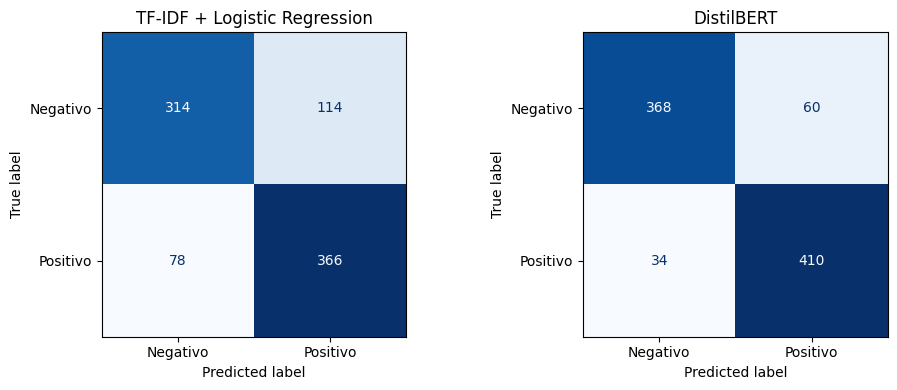

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    baseline_predictions,
    display_labels=["Negativo", "Positivo"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("TF-IDF + Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    transformer_predictions,
    display_labels=["Negativo", "Positivo"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("DistilBERT")

plt.tight_layout()
plt.show()


## 7. Análise qualitativa dos erros

A comparação abaixo procura exemplos em que os dois métodos discordam.


In [13]:
comparison = test_df.copy()
comparison["baseline"] = baseline_predictions
comparison["transformer"] = transformer_predictions

comparison["baseline_correct"] = comparison["baseline"] == comparison["label"]
comparison["transformer_correct"] = comparison["transformer"] == comparison["label"]

# Casos em que o Transformer acerta e o baseline erra.
transformer_wins = comparison[
    (~comparison["baseline_correct"]) &
    (comparison["transformer_correct"])
]

# Casos em que o baseline acerta e o Transformer erra.
baseline_wins = comparison[
    (comparison["baseline_correct"]) &
    (~comparison["transformer_correct"])
]

print("Transformer acerta / baseline erra")
display(transformer_wins.head(10))

print("\nBaseline acerta / Transformer erra")
display(baseline_wins.head(10))


Transformer acerta / baseline erra


,sentence,label,baseline,transformer,baseline_correct,transformer_correct
19,"in its best moments , resembles a bad high sch...",0,1,0,False,True
20,pumpkin takes an admirable look at the hypocri...,0,1,0,False,True
31,... designed to provide a mix of smiles and te...,0,1,0,False,True
37,( w ) hile long on amiable monkeys and worthy ...,0,1,0,False,True
39,"escaping the studio , piccoli is warmly affect...",1,0,1,False,True
42,the subtle strength of `` elling '' is that it...,1,0,1,False,True
45,it offers little beyond the momentary joys of ...,0,1,0,False,True
52,mr. tsai is a very original artist in his medi...,1,0,1,False,True
58,manages to be both repulsively sadistic and mu...,0,1,0,False,True
59,it 's just disappointingly superficial -- a mo...,0,1,0,False,True



Baseline acerta / Transformer erra


,sentence,label,baseline,transformer,baseline_correct,transformer_correct
33,if the movie succeeds in instilling a wary sen...,0,0,1,True,False
46,a synthesis of cliches and absurdities that se...,0,0,1,True,False
69,"this one is definitely one to skip , even for ...",0,0,1,True,False
115,sam mendes has become valedictorian at the sch...,0,0,1,True,False
121,it seems to me the film is about the art of ri...,0,0,1,True,False
142,what better message than ` love thyself ' coul...,1,1,0,True,False
166,characters still need to function according to...,0,0,1,True,False
205,falls neatly into the category of good stupid ...,1,1,0,True,False
215,the best revenge may just be living well becau...,1,1,0,True,False
249,huston nails both the glad-handing and the cho...,1,1,0,True,False


## 8. Conclusão


In [14]:
from IPython.display import Markdown, display

baseline_f1 = results.loc["TF-IDF + Logistic Regression", "F1"]
transformer_f1 = results.loc["DistilBERT", "F1"]
f1_gain = (transformer_f1 - baseline_f1) * 100

winner = results["F1"].idxmax()

conclusion = f'''
### Síntese dos resultados

O melhor F1 nesta execução foi obtido por **{winner}**.

- **F1 — TF-IDF + Regressão Logística:** {baseline_f1:.4f}
- **F1 — DistilBERT:** {transformer_f1:.4f}
- **Diferença:** {f1_gain:+.2f} pontos percentuais

O estudo compara duas formas distintas de representar linguagem:

- TF-IDF depende principalmente da presença e frequência de termos;
- DistilBERT gera representações contextuais, nas quais o significado de uma palavra depende da frase em que aparece.

### Limitações

- foi utilizado apenas um Transformer;
- o número de amostras de fine-tuning foi limitado para controlar custo de execução;
- SST-2 contém frases curtas de avaliações de filmes;
- sarcasmo, ambiguidade e dependência de contexto continuam difíceis;
- não foram comparados tempo, memória e custo computacional.

### Próximos experimentos

1. executar com todo o conjunto de treino;
2. comparar BERT, RoBERTa e modelos menores;
3. medir tempo, memória e custo;
4. avaliar exemplos adversariais;
5. testar zero-shot/few-shot com LLMs.
'''

display(Markdown(conclusion))



### Síntese dos resultados

O melhor F1 nesta execução foi obtido por **DistilBERT**.

- **F1 — TF-IDF + Regressão Logística:** 0.7922
- **F1 — DistilBERT:** 0.8972
- **Diferença:** +10.49 pontos percentuais

O estudo compara duas formas distintas de representar linguagem:

- TF-IDF depende principalmente da presença e frequência de termos;
- DistilBERT gera representações contextuais, nas quais o significado de uma palavra depende da frase em que aparece.

### Limitações

- foi utilizado apenas um Transformer;
- o número de amostras de fine-tuning foi limitado para controlar custo de execução;
- SST-2 contém frases curtas de avaliações de filmes;
- sarcasmo, ambiguidade e dependência de contexto continuam difíceis;
- não foram comparados tempo, memória e custo computacional.

### Próximos experimentos

1. executar com todo o conjunto de treino;
2. comparar BERT, RoBERTa e modelos menores;
3. medir tempo, memória e custo;
4. avaliar exemplos adversariais;
5. testar zero-shot/few-shot com LLMs.


## Referências

- SST-2 / GLUE — Hugging Face Datasets
- DistilBERT — Hugging Face Transformers
